In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import shutil
import random
from PIL import Image

# --- Paths ---
RAW_PATH = r"C:\Users\HP\Downloads\cats_and_dogs\kagglecatsanddogs_3367a\PetImages"
BASE_PATH = r"C:\Users\HP\Downloads\cats_and_dogs\dataset"  # cleaned split goes here

TRAIN_PATH = os.path.join(BASE_PATH, "training_set")
TEST_PATH  = os.path.join(BASE_PATH, "test_set")
VAL_PATH   = os.path.join(BASE_PATH, "validation_set")

# --- Split ratios ---
TRAIN_RATIO = 0.7
TEST_RATIO  = 0.15
VAL_RATIO   = 0.15  # leftover

# --- Fixed settings ---
IMG_SIZE = (64, 64)
EPOCHS = 15

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Test and val sets are loaded once (they don't change between experiments)
test_set = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

val_set = test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

print("Classes:", test_set.class_indices)

Found 3743 images belonging to 2 classes.
Found 3745 images belonging to 2 classes.
Classes: {'Cat': 0, 'Dog': 1}


In [11]:
def build_cnn(activation='relu', learning_rate=0.001, optimizer_name='adam'):
    """
    Same CNN architecture every run.
    Only the activation, optimizer, and learning rate change.
    """
    model = Sequential()

    # Conv Block 1
    model.add(Conv2D(32, kernel_size=3, activation=activation, input_shape=[64, 64, 3]))
    model.add(MaxPool2D(pool_size=2, strides=2))

    # Conv Block 2
    model.add(Conv2D(32, kernel_size=3, activation=activation))
    model.add(MaxPool2D(pool_size=2, strides=2))

    # Classifier
    model.add(Flatten())
    model.add(Dense(128, activation=activation))
    model.add(Dense(1, activation='sigmoid'))  # fixed for binary output

    # Optimizer selection
    if optimizer_name == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [12]:
configs = [
    # Baseline
    {"name": "Baseline (ReLU, Adam, 0.001)",  "activation": "relu",  "optimizer": "adam",    "lr": 0.001,  "batch_size": 32},

    # Activation functions
    {"name": "Activation: Tanh",              "activation": "tanh",  "optimizer": "adam",    "lr": 0.001,  "batch_size": 32},
    {"name": "Activation: ELU",               "activation": "elu",   "optimizer": "adam",    "lr": 0.001,  "batch_size": 32},

    # Optimizers
    {"name": "Optimizer: SGD",                "activation": "relu",  "optimizer": "sgd",     "lr": 0.001,  "batch_size": 32},
    {"name": "Optimizer: RMSprop",            "activation": "relu",  "optimizer": "rmsprop", "lr": 0.001,  "batch_size": 32},

    # Learning rates
    {"name": "LR: 0.01 (high)",               "activation": "relu",  "optimizer": "adam",    "lr": 0.01,   "batch_size": 32},
    {"name": "LR: 0.0001 (low)",              "activation": "relu",  "optimizer": "adam",    "lr": 0.0001, "batch_size": 32},

    # Batch sizes
    {"name": "Batch: 16",                     "activation": "relu",  "optimizer": "adam",    "lr": 0.001,  "batch_size": 16},
]

In [13]:
results = []
histories = {}

for i, cfg in enumerate(configs):
    print(f"\n{'='*60}")
    print(f"  [{i+1}/{len(configs)}] {cfg['name']}")
    print(f"{'='*60}")

    # Reload training set (augmentation resets each time, batch size may differ)
    train_set = train_datagen.flow_from_directory(
        TRAIN_PATH,
        target_size=IMG_SIZE,
        batch_size=cfg['batch_size'],
        class_mode='binary'
    )

    # Fresh model for each experiment
    model = build_cnn(
        activation=cfg['activation'],
        learning_rate=cfg['lr'],
        optimizer_name=cfg['optimizer']
    )

    history = model.fit(
        train_set,
        validation_data=test_set,
        epochs=EPOCHS,
        verbose=1
    )

    # Record final metrics
    results.append({
        "Experiment": cfg['name'],
        "Activation": cfg['activation'],
        "Optimizer": cfg['optimizer'],
        "Learning Rate": cfg['lr'],
        "Batch Size": cfg['batch_size'],
        "Train Acc": round(history.history['accuracy'][-1], 4),
        "Val Acc": round(history.history['val_accuracy'][-1], 4),
        "Val Loss": round(history.history['val_loss'][-1], 4)
    })

    histories[cfg['name']] = history.history

    # Free memory before next run
    del model
    tf.keras.backend.clear_session()


  [1/8] Baseline (ReLU, Adam, 0.001)
Found 17471 images belonging to 2 classes.


c:\tfenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 478s 871ms/step - accuracy: 0.6725 - loss: 0.6020 - val_accuracy: 0.7286 - val_loss: 0.5393
Epoch 2/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 111s 203ms/step - accuracy: 0.7503 - loss: 0.5117 - val_accuracy: 0.7724 - val_loss: 0.4704
Epoch 3/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 110s 202ms/step - accuracy: 0.7697 - loss: 0.4759 - val_accuracy: 0.7954 - val_loss: 0.4374
Epoch 4/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 107s 197ms/step - accuracy: 0.7856 - loss: 0.4490 - val_accuracy: 0.7895 - val_loss: 0.4548
Epoch 5/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 83s 152ms/step - accuracy: 0.7978 - loss: 0.4337 - val_accuracy: 0.8020 - val_loss: 0.4265
Epoch 6/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 102s 188ms/step - accuracy: 0.8073 - loss: 0.4128 - val_accuracy: 0.8063 - val_loss: 0.4174
Epoch 7/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 117s 214ms/step - accuracy: 0.8187 - loss: 0.4006 - val_accuracy: 0.8026 - val_loss: 0.4359
Epoch 8/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 116s 213ms/step - accuracy: 0.8259 - 

In [14]:
df = pd.DataFrame(results)
df = df.sort_values("Val Acc", ascending=False).reset_index(drop=True)
df.index += 1

print("\n")
print("=" * 105)
print("  FINAL COMPARISON (ranked by Validation Accuracy)")
print("=" * 105)
print(df.to_string())
print(f"\n  Best → {df.iloc[0]['Experiment']}  |  Val Acc: {df.iloc[0]['Val Acc']}")



  FINAL COMPARISON (ranked by Validation Accuracy)
                     Experiment Activation Optimizer  Learning Rate  Batch Size  Train Acc  Val Acc  Val Loss
1  Baseline (ReLU, Adam, 0.001)       relu      adam         0.0010          32     0.8700   0.8314    0.3903
2            Optimizer: RMSprop       relu   rmsprop         0.0010          32     0.8590   0.8186    0.4319
3                     Batch: 16       relu      adam         0.0010          16     0.8439   0.8173    0.4172
4               Activation: ELU        elu      adam         0.0010          32     0.8426   0.7978    0.4597
5              LR: 0.0001 (low)       relu      adam         0.0001          32     0.7913   0.7820    0.4584
6              Activation: Tanh       tanh      adam         0.0010          32     0.8102   0.7772    0.4784
7                Optimizer: SGD       relu       sgd         0.0010          32     0.6280   0.6139    0.6457
8               LR: 0.01 (high)       relu      adam         0.0100

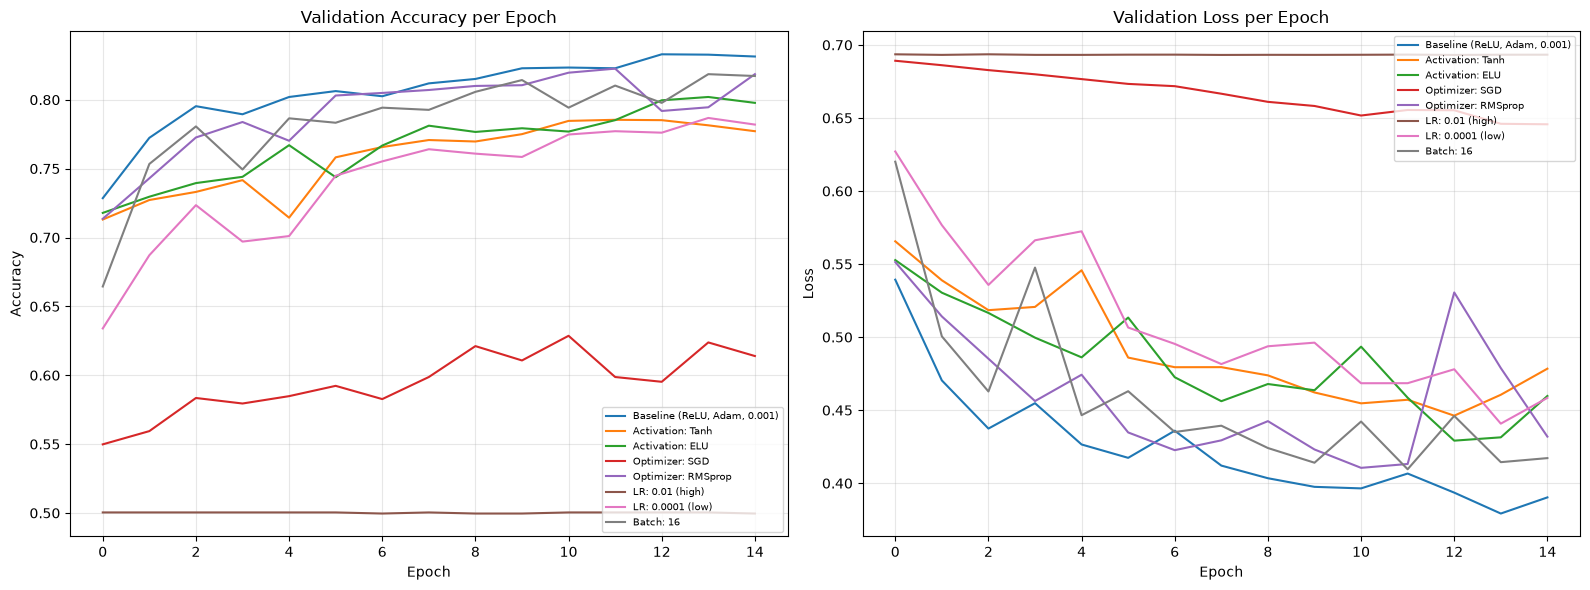

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, hist in histories.items():
    axes[0].plot(hist['val_accuracy'], label=name)
    axes[1].plot(hist['val_loss'], label=name)

axes[0].set_title("Validation Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=7, loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Validation Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=7, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_curves.png", dpi=150)
plt.show()

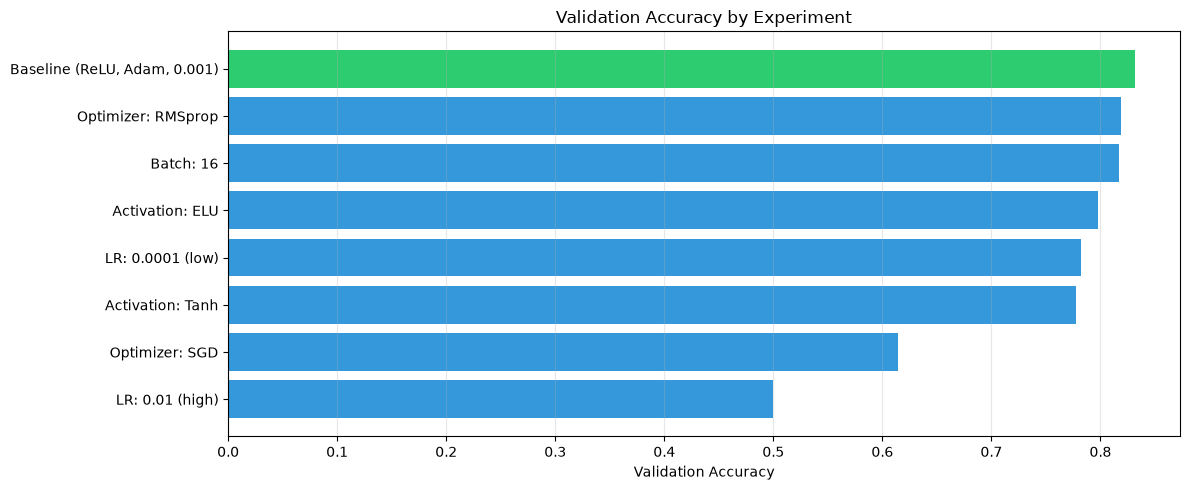

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df))]
ax.barh(df['Experiment'], df['Val Acc'], color=colors)
ax.set_xlabel("Validation Accuracy")
ax.set_title("Validation Accuracy by Experiment")
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("accuracy_bars.png", dpi=150)
plt.show()